### Ridge Regression Using OLS

#### Basic Working

In [1]:
from sklearn.datasets import load_diabetes
df = load_diabetes()

In [2]:
print(df.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
X = df.data
Y = df.target

In [4]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,45)

In [6]:
lr = LinearRegression()

In [7]:
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 23.45,-247.43, 492.11,..., 255.92, 794.22, 89.32]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.77,1.11,0.99,...,0.59,0.23,0.08]"


In [8]:
Y_pred = lr.predict(X_test)

In [9]:
from sklearn.metrics import mean_squared_error
print("R2 Score:",r2_score(Y_test,Y_pred))
print("RMSE:",np.sqrt(mean_squared_error(Y_test,Y_pred)))

R2 Score: 0.5188113124539249
RMSE: 48.72713760953252


In [11]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.0001)

In [12]:
R.fit(X_train,Y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'sag

In [13]:
Y_pred1 = R.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error
print("R2 Score:",r2_score(Y_test,Y_pred1))
print("RMSE:",np.sqrt(mean_squared_error(Y_test,Y_pred1)))

R2 Score: 0.5189732635884952
RMSE: 48.71893700181955


#### Overfitting Analysis

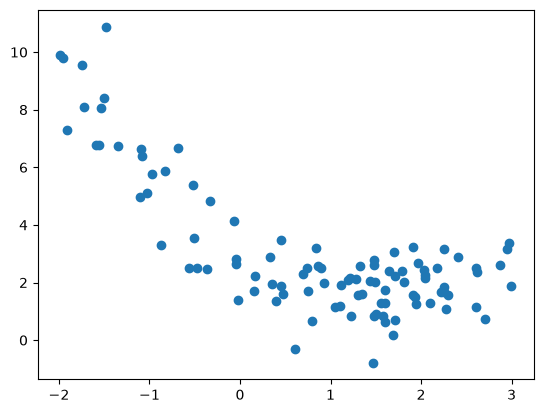

In [15]:
m = 100
x1 = 5 * np.random.rand(m,1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m,1)
plt.scatter(x1,x2)
plt.show()

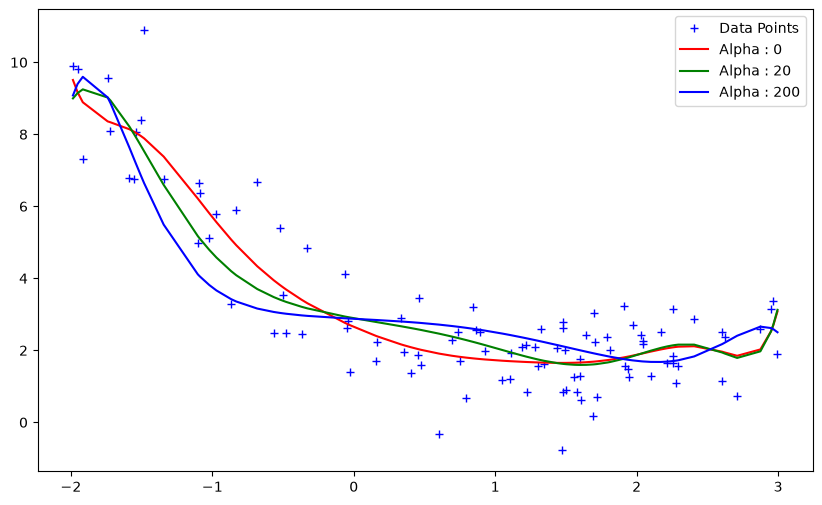

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
def custom_ridge(x1,x2,alpha):
    model = Pipeline([
        ('poly_feats',PolynomialFeatures(degree=10)),
        ('ridge',Ridge(alpha=alpha))
         ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0,20,200]
cs = ['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label='Data Points')

for alpha,c in zip(alphas,cs):
    preds = custom_ridge(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c,label='Alpha : {}'.format(alpha))

plt.legend()
plt.show()

#### Ridge On 2D Data 

In [1]:
from sklearn.datasets import make_regression

In [2]:
X,Y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

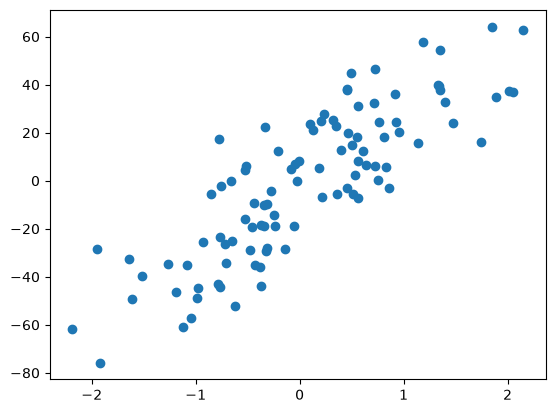

In [3]:
plt.scatter(X,Y)

In [4]:
lr = LinearRegression()
lr.fit(X,Y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [5]:
from sklearn.linear_model import Ridge
rdg = Ridge(alpha=10)
rdg.fit(X,Y)
print(rdg.coef_)
print(rdg.intercept_)

[24.9546267]
-2.1269130035235735


In [6]:
rdg1 = Ridge(alpha=100)
rdg1.fit(X,Y)
print(rdg1.coef_)
print(rdg1.intercept_)

[12.93442104]
-1.4248441496033308


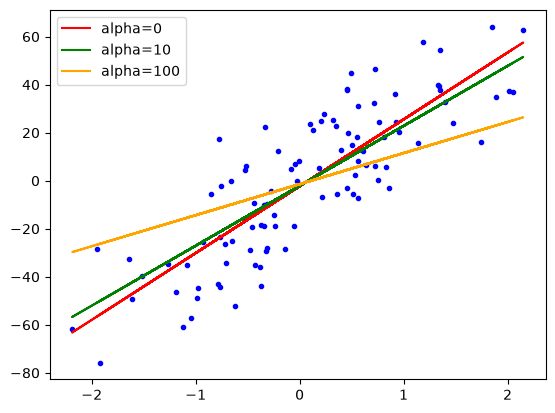

In [8]:
plt.plot(X,Y,'b.')
# lr - overfit
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
# ridge - optimal
plt.plot(X,rdg.predict(X),color='green',label='alpha=10')
# ridge - underfit
plt.plot(X,rdg1.predict(X),color='orange',label='alpha=100')
plt.legend()

In [13]:
class custom_ridge_reg:
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self,X,Y):
        num,den = 0,0
        for i in range(X.shape[0]):
            num += (Y[i]- Y.mean()) * (X[i]- X.mean())
            den += (X[i]- X.mean())**2
        den += self.alpha
        self.m = num / den
        self.b = Y.mean() - (self.m * X.mean())
        print(self.m,self.b)

    def predict(self,X):
        pass

In [16]:
crgd = custom_ridge_reg(alpha=100)

In [17]:
crgd.fit(X,Y)

[12.93442104] [-1.42484415]


#### Ridge On N-D Data

In [18]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [19]:
X,Y = load_diabetes(return_X_y=True)

In [20]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,4)

In [21]:
from sklearn.linear_model import Ridge

In [22]:
reg = Ridge(alpha=0.1,solver='cholesky')

In [23]:
reg.fit(X_train,Y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.1
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'cholesky'
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'sa

In [25]:
Y_pred = reg.predict(X_test)
r2_score(Y_test,Y_pred)

0.46931288533098037

In [26]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [33]:
class custom_ndim_ridge:
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X,Y):
        X = np.insert(X,0,1,axis=1)
        idt = np.identity(X.shape[1])
        idt[0][0] = 0
        res = np.linalg.inv(np.dot(X.T,X) + self.alpha * idt).dot(X.T).dot(Y)
        self.intercept_ = res[0]
        self.coef_ = res[1:]

    def predict(self,X):
        return np.dot(X,self.coef_) + self.intercept_

In [34]:
nd_reg = custom_ndim_ridge()
nd_reg.fit(X_train,Y_train)
Y_pred = nd_reg.predict(X_test)
print(r2_score(Y_test,Y_pred))
print(nd_reg.coef_)
print(nd_reg.intercept_)

0.46931288533098037
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.8905342560281


### Ridge Regression Using Gradient Descent

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score

In [2]:
X,Y = load_diabetes(return_X_y=True)

In [3]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,4)

In [4]:
from sklearn.linear_model import SGDRegressor

In [7]:
reg = SGDRegressor(penalty='l2',max_iter=100,eta0=0.1,learning_rate='constant',alpha=0.001)

In [9]:
reg.fit(X_train,Y_train)
Y_pred = reg.predict(X_test)
print("R2 Score(Ridge):",r2_score(Y_test,Y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 Score(Ridge): 0.45361730513106036
[  48.92368476 -163.39346887  371.92742947  273.92199116   -4.83461655
  -57.10671851 -169.22043473  141.38626367  336.43200773   93.53202239]
[162.70024918]


In [13]:
from sklearn.linear_model import Ridge
reg1 = Ridge(alpha=0.001,max_iter=500,solver='sparse_cg')

In [14]:
reg1.fit(X_train,Y_train)
Y_pred1 = reg1.predict(X_test)
print("R2 Score:",r2_score(Y_test,Y_pred1))
print(reg1.coef_)
print(reg1.intercept_)

R2 Score: 0.4625010162198224
[  34.52193944 -290.84082851  482.40183323  368.06788479 -852.44871027
  501.59162476  180.11113913  270.76336754  759.73536941   37.4913747 ]
151.1019852231466


In [24]:
class custom_ridge_gd:
    def __init__(self,epochs,learning_rate,alpha):
        self.rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept = None

    def fit(self,X,Y):
        self.coef_ = np.ones(X.shape[1])
        self.intercept_ = 0
        # np.insert(resultant_df,insertion_pos,data_to_insert)
        theta = np.insert(self.coef_,0,self.intercept_)
        X = np.insert(X,0,1,axis=1)
        for i in range(self.epochs):
            theta_der = np.dot(X.T,X).dot(theta) - np.dot(X.T,Y) - self.alpha * theta
            theta -= self.rate * theta_der

        self.coef_ =  theta[1:]
        self.intercept_ = theta[0]

    def predict(self,X):
        return np.dot(X,self.coef_) + self.intercept_

In [25]:
reg2 = custom_ridge_gd(epochs=500,alpha=0.001,learning_rate=0.005)

In [26]:
reg2.fit(X_train,Y_train)
Y_pred2 = reg.predict(X_test)
print("R2 Score:",r2_score(Y_test,Y_pred2))
print(reg2.coef_)
print(reg2.intercept_)

R2 Score: 0.45361730513106036
[  46.62140947 -221.88627741  452.72916665  325.94986339  -29.28550185
  -96.76767049 -191.05382527  146.37675246  401.31596569   95.03232584]
150.8690793692947


### Interview Key Points

#### Q1. How the coefficients get affected?
#### Q2. What Will be the impacts On Coefficients Having Higher Magnitude?

In [27]:
from sklearn.datasets import load_diabetes

In [28]:
data = load_diabetes()

In [29]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

In [30]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [32]:
df.shape

(442, 11)

In [34]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [37]:
coefs = []
r2_scores = []

for i in [0,10,100,1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train,Y_train)
    coefs.append(reg.coef_.tolist())
    Y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(Y_test,Y_pred))

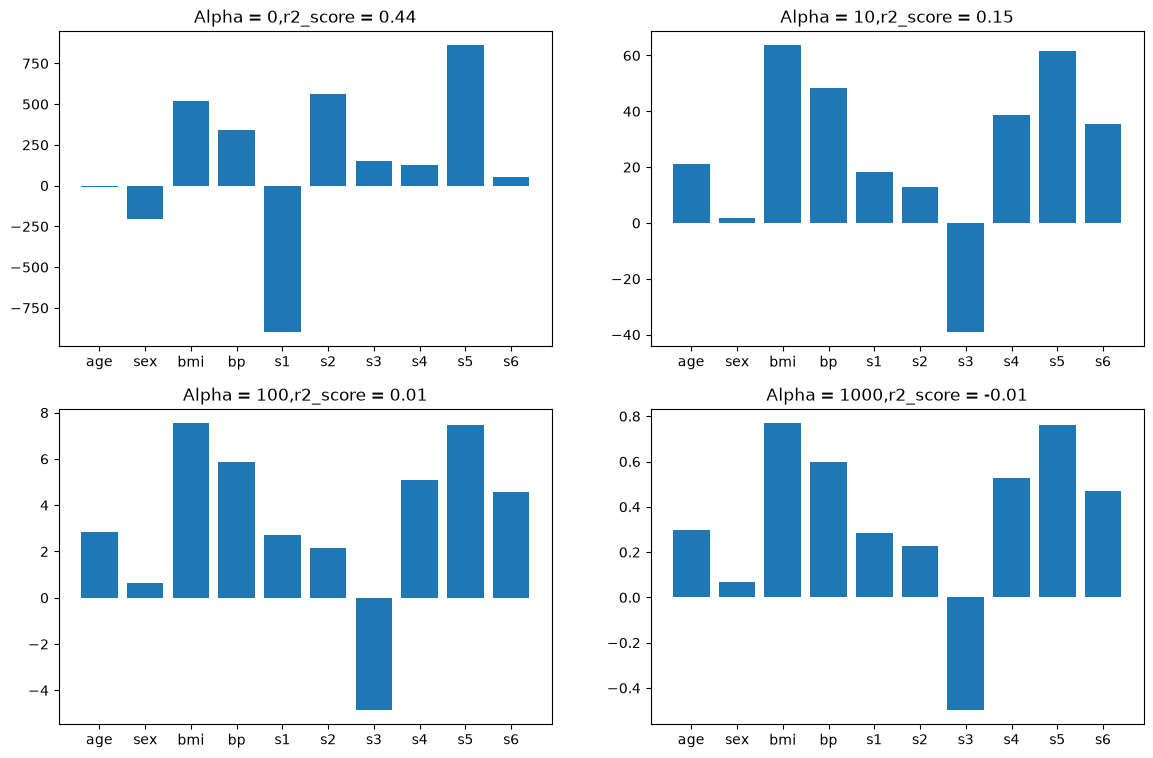

In [38]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0,r2_score = {}'.format(round(r2_scores[0],2)))
plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10,r2_score = {}'.format(round(r2_scores[1],2)))
plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100,r2_score = {}'.format(round(r2_scores[2],2)))
plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000,r2_score = {}'.format(round(r2_scores[3],2)))
plt.show()
# This Graph is evident of shrinking effect of coeffficients on increasing alpha.

In [39]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]
coefs = []
for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,Y_train)
    coefs.append(reg.coef_.tolist())

In [40]:
inp_arr = np.array(coefs)

In [41]:
coef_df = pd.DataFrame(inp_arr,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


In [43]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.01,0.05,0.1,1,5,10]
coefs = []
for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,Y_train)
    coefs.append(reg.coef_.tolist())

In [45]:
inp_arr1 = np.array(coefs).T

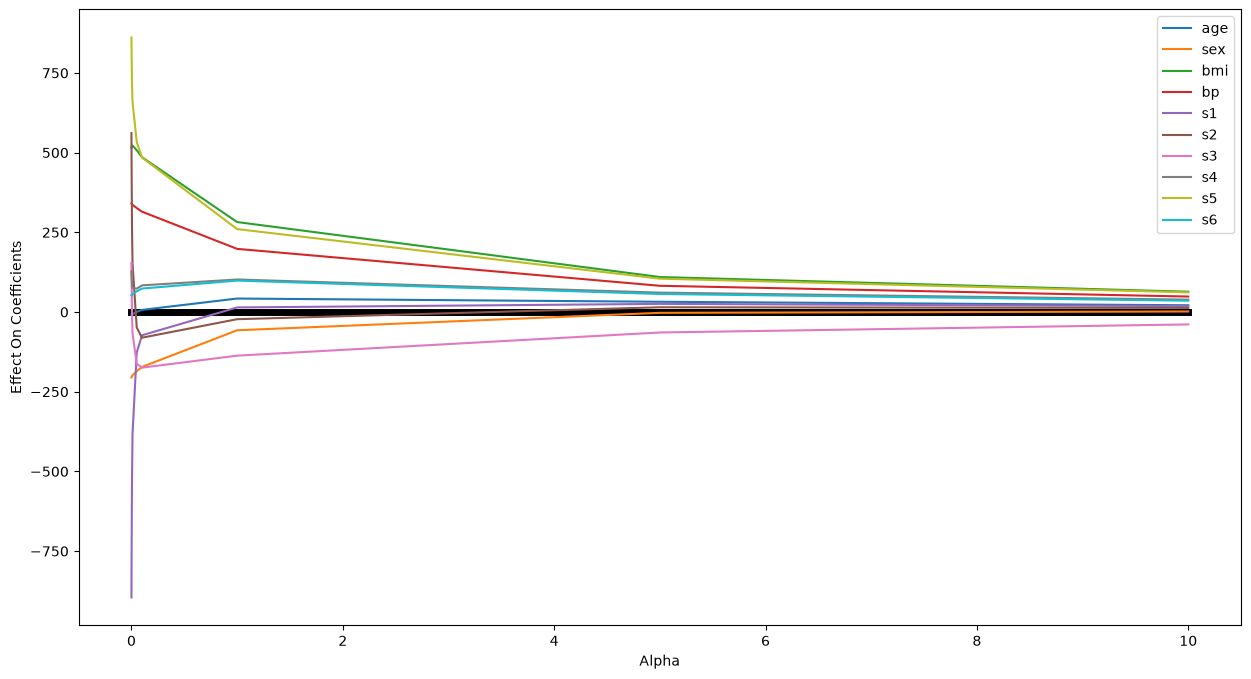

In [47]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(inp_arr1.shape[0]):
    plt.plot(alphas,inp_arr1[i],label=data.feature_names[i])
    plt.xlabel("Alpha")
    plt.ylabel("Effect On Coefficients")
plt.legend()
# all coefficients converges to zero,higher value are more affected

#### 3. Bias Variance Trade Off

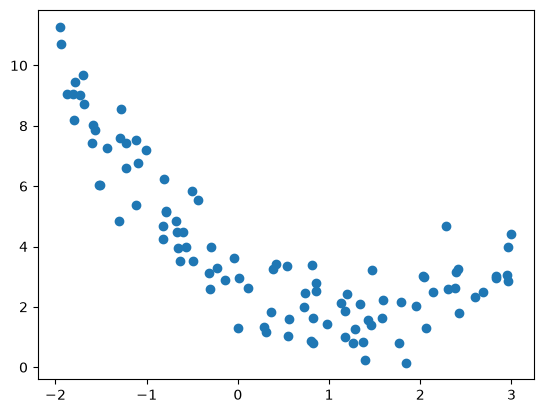

In [1]:
m = 100
X = 5 * np.random.rand(m,1) - 2
Y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m,1)
plt.scatter(X,Y)
plt.show()

In [5]:
X_train,X_test,Y_train,Y_test = train(X.reshape(100,1),Y.reshape(100),0.2,2)

In [6]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [7]:
from mlxtend.evaluate import bias_variance_decomp
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
alphas = np.linspace(0,30,100)
loss = []
bias = []
variance = []
for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss,avg_bias,avg_var = bias_variance_decomp(reg,X_train_trans,Y_train,X_test_trans,Y_test, loss='mse',random_seed = 123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.011561564974049e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0765687880968906e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0903683960774426e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.795066018783161e

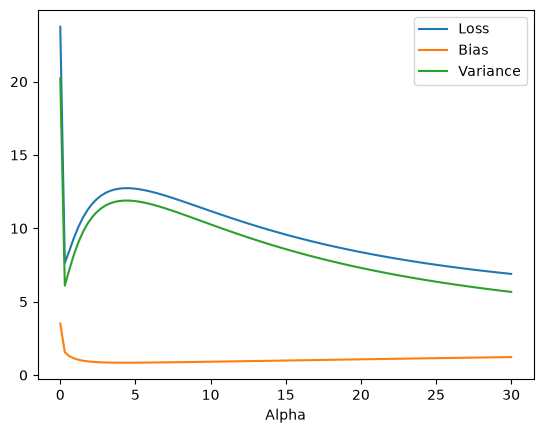

In [10]:
plt.plot(alphas,loss,label='Loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
# plt.ylim(0,5)
plt.xlabel("Alpha")
plt.legend()

In [13]:
class find_optimal_bias_var:
    def __init__(self,degree):
        self.degree = degree

    def train(self,X,Y):
        X_train,X_test,Y_train,Y_test = train(X.reshape(100,1),Y.reshape(100),0.2,2)
        poly = PolynomialFeatures(degree=self.degree)
        X_train_trans = poly.fit_transform(X_train)
        X_test_trans = poly.transform(X_test)
        alphas = np.linspace(0,30,100)
        loss = []
        bias = []
        variance = []
        for i in alphas:
            reg = Ridge(alpha=i)
            avg_expected_loss,avg_bias,avg_var = bias_variance_decomp(reg,X_train_trans,Y_train,X_test_trans,Y_test, loss='mse',random_seed = 123)
            loss.append(avg_expected_loss)
            bias.append(avg_bias)
            variance.append(avg_var)

        plt.plot(alphas,loss,label='Loss')
        plt.plot(alphas,bias,label='Bias')
        plt.plot(alphas,variance,label='Variance')
        plt.ylim(0,5)
        plt.xlabel("Alpha")
        plt.legend()

In [14]:
opt = find_optimal_bias_var(degree=14)

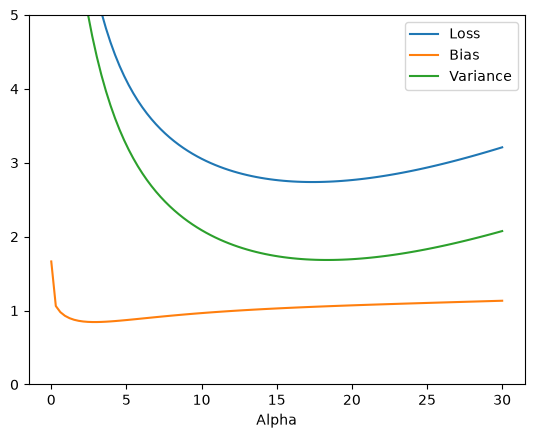

In [15]:
opt.train(X,Y)

#### 4.Effect Of Regularization On Loss Function

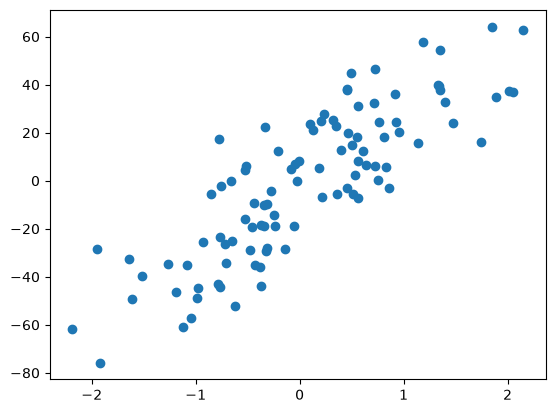

In [16]:
from sklearn.datasets import make_regression
X,Y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)
plt.scatter(X,Y)

In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,Y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [18]:
def cal_loss(m,alpha):
    return np.sum((Y-m*X.ravel() + 2.29)**2) + alpha * m * m

In [ ]:
def predict(m):
    return m*X - 2.29

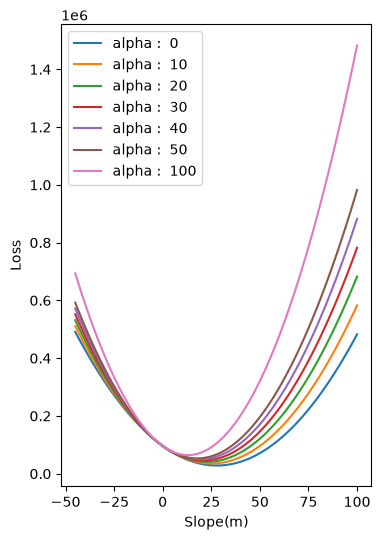

In [23]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha :  {}'.format(j))
plt.legend()
plt.xlabel('Slope(m)')
plt.ylabel('Loss')
plt.show()